# Portfolio Optimization: Lagrange Multipliers and Kuhn–Tucker Conditions

Companion notebook to Elton, Gruber, Brown & Goetzmann, *Modern Portfolio Theory and Investment Analysis*.

**Road map**

| Part | Problem | Method |
|---|---|---|
| 1 | Two assets, no optimization | Direct formulas, correlation sweep |
| 2 | $\min \sigma_p^2$ s.t. $X'\mathbf{1}=1$ | Lagrangian, one equality constraint |
| 3 | $\min \sigma_p^2$ s.t. $X'R=R_p^*,\ X'\mathbf{1}=1$ | Lagrangian, two equality constraints |
| 4 | $\max \theta=(R_p-R_f)/\sigma_p$ | Linear system in $Z=\lambda X$ |
| 5 | Part 3 **plus** $X_i\ge 0$ | Quadratic program, Kuhn–Tucker conditions |
| 6 | Part 5 with $\sum_i \lvert X_i\rvert = 1$ | Lintner's short-sale definition |

Throughout: $R$ = vector of expected returns, $\Sigma$ = variance–covariance matrix, $X$ = weight vector,
$\mathbf{1}$ = vector of ones, $R_f$ = risk-free rate.

## Setup

### The universe

Five asset classes with illustrative *annualized* numbers. The correlation structure is the point of interest:
domestic equities are strongly correlated with each other, international developed sits between domestic and
emerging markets, and investment-grade bonds are almost uncorrelated with everything.

The covariance matrix is built as $\Sigma = D\,C\,D$ where $D=\operatorname{diag}(\sigma_1,\dots,\sigma_n)$
and $C$ is the correlation matrix. Built this way, $\Sigma$ is symmetric; the eigenvalue check below confirms
it is also positive definite, which is what makes $\Sigma^{-1}$ exist and the quadratic form
$X'\Sigma X$ strictly convex (so every optimum we find is *the* global optimum).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def _fmt(v):
    return f"{v: .4f}"

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.float_format", _fmt)
plt.rcParams.update({"figure.figsize": (8, 5.5), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11})

# --- assets -----------------------------------------------------------------
names = ["US Large Cap", "US Small Cap", "Intl Developed", "Emerging Mkts", "Agg Bonds"]
n     = len(names)

R  = np.array([0.090, 0.115, 0.080, 0.105, 0.055])   # expected returns E(R_i)
sd = np.array([0.160, 0.220, 0.180, 0.240, 0.060])   # standard deviations sigma_i

Corr = np.array([
    [1.00, 0.80, 0.75, 0.65, 0.05],
    [0.80, 1.00, 0.65, 0.60, 0.00],
    [0.75, 0.65, 1.00, 0.70, 0.05],
    [0.65, 0.60, 0.70, 1.00, 0.00],
    [0.05, 0.00, 0.05, 0.00, 1.00],
])

Sigma = np.outer(sd, sd) * Corr        # Sigma = D C D
one   = np.ones(n)
Rf    = 0.05                           # risk-free rate, change freely

In [2]:
# --- display the inputs -----------------------------------------------------
inputs = pd.DataFrame({"E(R)": R, "sigma": sd, "Sharpe (excess/sigma)": (R - Rf) / sd}, index=names)
print("Expected returns and risk\n"); print(inputs); print()

print("Correlation matrix C\n"); print(pd.DataFrame(Corr, index=names, columns=names)); print()

print("Variance-covariance matrix Sigma\n")
print(pd.DataFrame(Sigma, index=names, columns=names).round(5)); print()

# positive definiteness: all eigenvalues > 0
eigs = np.linalg.eigvalsh(Sigma)
print("Eigenvalues of Sigma:", np.round(eigs, 6))
print("Positive definite:", bool(np.all(eigs > 0)), "| condition number:", round(eigs.max() / eigs.min(), 1))

Expected returns and risk

                  E(R)   sigma  Sharpe (excess/sigma)
US Large Cap    0.0900  0.1600                 0.2500
US Small Cap    0.1150  0.2200                 0.2955
Intl Developed  0.0800  0.1800                 0.1667
Emerging Mkts   0.1050  0.2400                 0.2292
Agg Bonds       0.0550  0.0600                 0.0833

Correlation matrix C

                US Large Cap  US Small Cap  Intl Developed  Emerging Mkts  \
US Large Cap          1.0000        0.8000          0.7500         0.6500   
US Small Cap          0.8000        1.0000          0.6500         0.6000   
Intl Developed        0.7500        0.6500          1.0000         0.7000   
Emerging Mkts         0.6500        0.6000          0.7000         1.0000   
Agg Bonds             0.0500        0.0000          0.0500         0.0000   

                Agg Bonds  
US Large Cap       0.0500  
US Small Cap       0.0000  
Intl Developed     0.0500  
Emerging Mkts      0.0000  
Agg Bonds          1.00

In [3]:
# --- portfolio helper functions ---------------------------------------------
def port_return(X, R=R):
    '''E(R_p) = X'R'''
    return float(X @ R)

def port_var(X, Sigma=Sigma):
    '''sigma_p^2 = X'Sigma X'''
    return float(X @ Sigma @ X)

def port_sd(X, Sigma=Sigma):
    '''sigma_p = sqrt(X'Sigma X)'''
    return float(np.sqrt(port_var(X, Sigma)))

def summarize(X, label):
    '''Print weights, return, risk and Sharpe ratio of a portfolio.'''
    r, s = port_return(X), port_sd(X)
    print(f"{label}")
    print(pd.Series(X, index=names, name="weight").to_frame().T)
    print(f"  E(Rp) = {r:.4%}   sigma_p = {s:.4%}   sum(X) = {X.sum():.4f}   "
          f"theta = {(r - Rf) / s:.4f}\n")
    return r, s

**Interpretation.** All five eigenvalues are strictly positive, so $\Sigma$ is positive definite: the
variance function has a unique interior minimum and the first-order conditions we derive below are necessary
*and* sufficient. Note that with $R_f = 5\%$, bonds carry only $0.5\%$ of expected excess return — that low
reward-to-risk ratio will show up later as a large but shrinking bond position along the frontier.

## Part 1 — Two assets: how correlation bends the curve

With two assets and weights $X_1$, $X_2 = 1 - X_1$:

$$E(R_p) = X_1 R_1 + X_2 R_2$$
$$\sigma_p^2 = X_1^2\sigma_1^2 + X_2^2\sigma_2^2 + 2X_1X_2\sigma_1\sigma_2\rho_{12}$$

No optimization yet — this is just the opportunity set traced out as $X_1$ varies. Values $X_1 > 1$
(equivalently $X_2 < 0$) mean shorting asset 2 and putting the proceeds into asset 1.

The only term that depends on $\rho_{12}$ is the cross term, and it enters *linearly*. Lower correlation
shrinks $\sigma_p$ at every $X_1$ without touching $E(R_p)$ at all, so the whole curve is pushed left as
$\rho$ falls: this is diversification, in one equation.

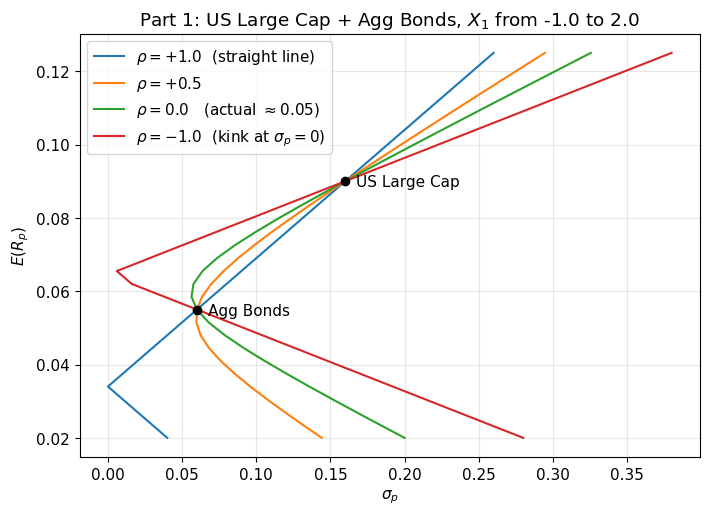

     X1      X2   E(Rp)  sd(rho=+1)  sd(rho=0)  sd(rho=-1)
-1.0000  2.0000  0.0200      0.0400     0.2000      0.2800
-0.5000  1.5000  0.0375      0.0100     0.1204      0.1700
-0.0000  1.0000  0.0550      0.0600     0.0600      0.0600
 0.5000  0.5000  0.0725      0.1100     0.0854      0.0500
 1.0000  0.0000  0.0900      0.1600     0.1600      0.1600
 1.5000 -0.5000  0.1075      0.2100     0.2419      0.2700
 2.0000 -1.0000  0.1250      0.2600     0.3256      0.3800


In [4]:
# Asset 1 = US Large Cap (i=0), Asset 2 = Agg Bonds (i=4)
i1, i2 = 0, 4
R1, R2   = R[i1], R[i2]
sd1, sd2 = sd[i1], sd[i2]

X1 = np.arange(-1.0, 2.0 + 1e-9, 0.1)      # sweep, short sales allowed
X2 = 1.0 - X1

Rp_2a = X1 * R1 + X2 * R2                  # independent of rho

def sd_two_asset(rho):
    '''sigma_p for the two-asset portfolio at every X1 in the sweep, given rho.'''
    var = X1**2 * sd1**2 + X2**2 * sd2**2 + 2 * X1 * X2 * sd1 * sd2 * rho
    return np.sqrt(var)

rhos = [1.0, 0.5, 0.0, -1.0]
curves = np.array([sd_two_asset(r) for r in rhos])   # shape (4, len(X1))

fig, ax = plt.subplots()
ax.plot(curves[0], Rp_2a, label=r"$\rho = +1.0$  (straight line)")
ax.plot(curves[1], Rp_2a, label=r"$\rho = +0.5$")
ax.plot(curves[2], Rp_2a, label=r"$\rho = 0.0$   (actual $\approx 0.05$)")
ax.plot(curves[3], Rp_2a, label=r"$\rho = -1.0$  (kink at $\sigma_p=0$)")
ax.scatter([sd1, sd2], [R1, R2], color="black", zorder=5)
ax.annotate(names[i1], (sd1, R1), textcoords="offset points", xytext=(8, -4))
ax.annotate(names[i2], (sd2, R2), textcoords="offset points", xytext=(8, -4))
ax.set_xlabel(r"$\sigma_p$"); ax.set_ylabel(r"$E(R_p)$")
ax.set_title(f"Part 1: {names[i1]} + {names[i2]}, $X_1$ from -1.0 to 2.0")
ax.legend(); plt.show()

print(pd.DataFrame({"X1": X1, "X2": X2, "E(Rp)": Rp_2a,
                    "sd(rho=+1)": curves[0], "sd(rho=0)": curves[2], "sd(rho=-1)": curves[3]}
                   ).iloc[::5].to_string(index=False))

**Interpretation.** At $\rho=+1$ the two assets are redundant and the opportunity set collapses to a
straight line: no risk reduction is available. As $\rho$ falls the curve bows to the left, and at $\rho=-1$ it
becomes two straight segments meeting at $\sigma_p = 0$ — a perfect hedge exists. Every curve passes through
the same two endpoints (the individual assets) because correlation never affects $E(R_p)$. The realistic case
here, $\rho \approx 0.05$, sits close to the $\rho = 0$ curve and already delivers a minimum-variance mix
noticeably to the left of the bond position alone.

## Part 2 — Global minimum variance portfolio (one equality constraint)

Minimize variance subject *only* to the budget constraint. No target return yet:

$$\min_X \tfrac{1}{2} X'\Sigma X \quad \text{s.t.} \quad X'\mathbf{1} = 1$$

Lagrangian:

$$L = \tfrac{1}{2}X'\Sigma X - \lambda\,(X'\mathbf{1} - 1)$$

First-order conditions ($n+1$ equations, $n+1$ unknowns):

$$\frac{\partial L}{\partial X} = \Sigma X - \lambda\mathbf{1} = 0
\quad\Longrightarrow\quad X = \lambda\,\Sigma^{-1}\mathbf{1}$$
$$\frac{\partial L}{\partial \lambda} = -(X'\mathbf{1} - 1) = 0
\quad\Longrightarrow\quad X'\mathbf{1} = 1$$

Substituting the first into the second gives $\lambda = 1/(\mathbf{1}'\Sigma^{-1}\mathbf{1})$ and hence

$$\boxed{\;X^{*} = \frac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}'\Sigma^{-1}\mathbf{1}}\;}$$

The $\tfrac{1}{2}$ in front of the variance is pure convenience — it cancels the 2 from differentiating the
quadratic form and only rescales $\lambda$. Numerically we use `np.linalg.solve(Sigma, one)` rather than
`np.linalg.inv(Sigma) @ one`: same answer, better conditioning, fewer flops.

In [5]:
# Sigma^{-1} 1 and Sigma^{-1} R appear everywhere below; compute once.
Sinv_1 = np.linalg.solve(Sigma, one)     # Sigma^{-1} 1
Sinv_R = np.linalg.solve(Sigma, R)       # Sigma^{-1} R

# The four standard scalars of the mean-variance algebra
A_ = one @ Sinv_1        # 1' Sigma^{-1} 1
B_ = one @ Sinv_R        # 1' Sigma^{-1} R
C_ = R   @ Sinv_R        # R' Sigma^{-1} R
D_ = A_ * C_ - B_**2     # determinant of the 2x2 constraint system, > 0

X_gmv = Sinv_1 / A_                      # closed-form GMV weights
lam_gmv = 1.0 / A_                       # the Lagrange multiplier itself

print(f"A = 1'S^-1 1 = {A_:.4f}   B = 1'S^-1 R = {B_:.4f}   "
      f"C = R'S^-1 R = {C_:.4f}   D = AC - B^2 = {D_:.4f}\n")
R_gmv, sd_gmv = summarize(X_gmv, "Global minimum variance portfolio (short sales allowed)")
print(f"Lagrange multiplier lambda = {lam_gmv:.6f}   "
      f"(= sigma_gmv^2 = {port_var(X_gmv):.6f}, since X*'Sigma X* = lambda * X*'1)")

# Comparison against the naive alternatives
print(f"\nEqual-weight portfolio sigma: {port_sd(one / n):.4%}")
print(f"Lowest single-asset sigma:    {sd.min():.4%} ({names[int(sd.argmin())]})")
print(f"GMV sigma:                    {sd_gmv:.4%}")

A = 1'S^-1 1 = 308.4286   B = 1'S^-1 R = 18.1887   C = R'S^-1 R = 1.1541   D = AC - B^2 = 25.1189

Global minimum variance portfolio (short sales allowed)
        US Large Cap  US Small Cap  Intl Developed  Emerging Mkts  Agg Bonds
weight        0.0796        0.0038          0.0212         0.0086     0.8868
  E(Rp) = 5.8972%   sigma_p = 5.6941%   sum(X) = 1.0000   theta = 0.1576

Lagrange multiplier lambda = 0.003242   (= sigma_gmv^2 = 0.003242, since X*'Sigma X* = lambda * X*'1)

Equal-weight portfolio sigma: 14.0627%
Lowest single-asset sigma:    6.0000% (Agg Bonds)
GMV sigma:                    5.6941%


In [6]:
# --- sanity check: closed form vs brute-force sweep on the 2-asset subset ----
sub = [i1, i2]                                   # Large Cap + Bonds, as in Part 1
Sigma_sub = Sigma[np.ix_(sub, sub)]
X_gmv_sub = np.linalg.solve(Sigma_sub, np.ones(2))
X_gmv_sub /= X_gmv_sub.sum()

grid  = np.arange(-1.0, 2.0 + 1e-9, 0.001)       # fine sweep over X1
Xg    = np.column_stack([grid, 1 - grid])
var_g = np.einsum("ij,jk,ik->i", Xg, Sigma_sub, Xg)   # X'Sigma X for every row
k     = int(var_g.argmin())

print(f"Closed form  : X1 = {X_gmv_sub[0]: .5f}, X2 = {X_gmv_sub[1]: .5f}, "
      f"sigma = {np.sqrt(X_gmv_sub @ Sigma_sub @ X_gmv_sub):.6%}")
print(f"Brute sweep  : X1 = {grid[k]: .5f}, X2 = {1 - grid[k]: .5f}, "
      f"sigma = {np.sqrt(var_g[k]):.6%}")
print(f"Difference in X1: {abs(X_gmv_sub[0] - grid[k]):.2e}  (grid step is 0.001)")

Closed form  : X1 =  0.11048, X2 =  0.88952, sigma = 5.705521%
Brute sweep  : X1 =  0.11000, X2 =  0.89000, sigma = 5.705527%
Difference in X1: 4.82e-04  (grid step is 0.001)


**Interpretation.** The GMV portfolio is dominated by bonds (~89%) with a small equity sleeve. That
equity slice is not there for return — the objective ignores returns entirely — it is there because the
equity–bond correlation is near zero, so a few percent of stocks *lowers* total variance. The multiplier
$\lambda$ equals the GMV variance itself, which follows from $X^{*\prime}\Sigma X^{*} = \lambda X^{*\prime}\mathbf{1} = \lambda$.
And the brute-force sweep on the two-asset subset lands on the closed-form answer to within one grid step,
which confirms the algebra.

## Part 3 — The efficient frontier (two equality constraints)

Now pin the expected return to a target $R_p^*$:

$$\min_X \tfrac{1}{2}X'\Sigma X \quad \text{s.t.} \quad X'R = R_p^*, \quad X'\mathbf{1} = 1$$

$$L = \tfrac{1}{2}X'\Sigma X - \lambda_1 (X'R - R_p^{*}) - \lambda_2 (X'\mathbf{1} - 1)$$

First-order conditions:

$$\frac{\partial L}{\partial X} = \Sigma X - \lambda_1 R - \lambda_2\mathbf{1} = 0, \qquad
X'R = R_p^{*}, \qquad X'\mathbf{1} = 1$$

which is a linear system of $n+2$ equations in $n+2$ unknowns $[X;\lambda_1;\lambda_2]$:

$$\begin{bmatrix} \Sigma & -R & -\mathbf{1} \\ R' & 0 & 0 \\ \mathbf{1}' & 0 & 0 \end{bmatrix}
\begin{bmatrix} X \\ \lambda_1 \\ \lambda_2 \end{bmatrix} =
\begin{bmatrix} \mathbf{0} \\ R_p^{*} \\ 1 \end{bmatrix}$$

Because the system is linear in the right-hand side, and $R_p^*$ enters only there, the solution is **affine
in the target return**:

$$X(R_p^{*}) = g + h\,R_p^{*}, \qquad
g = \frac{C\,\Sigma^{-1}\mathbf{1} - B\,\Sigma^{-1}R}{D}, \qquad
h = \frac{A\,\Sigma^{-1}R - B\,\Sigma^{-1}\mathbf{1}}{D}$$

with $A,B,C,D$ from Part 2. This is the *two-fund separation* result: every frontier portfolio is a
combination of the two fixed portfolios $g$ and $g+h$. Substituting back gives the frontier hyperbola

$$\sigma_p^2(R_p^{*}) = \frac{A R_p^{*2} - 2B R_p^{*} + C}{D}$$

Minimizing that over $R_p^*$ gives $R_{gmv} = B/A$ and $\sigma^2_{gmv} = 1/A$ — the Part 2 answer, recovered.

We implement the block system explicitly (it *is* the FOCs, one line of code) and then use the affine form to
sweep the whole frontier without re-solving anything.

In [7]:
def frontier_block_solve(Rp_target):
    '''Solve the (n+2)x(n+2) first-order-condition system directly.
    Returns (X, lambda_1, lambda_2). This matrix IS dL/dX = 0 plus the two constraints.'''
    M = np.zeros((n + 2, n + 2))
    M[:n, :n]  = Sigma
    M[:n,  n]  = -R
    M[:n,  n+1] = -one
    M[n,  :n]  = R
    M[n+1, :n] = one
    rhs = np.concatenate([np.zeros(n), [Rp_target], [1.0]])
    sol = np.linalg.solve(M, rhs)
    return sol[:n], sol[n], sol[n + 1]

# The affine (closed-form) version: X(Rp) = g + h*Rp
g_vec = (C_ * Sinv_1 - B_ * Sinv_R) / D_
h_vec = (A_ * Sinv_R - B_ * Sinv_1) / D_

# Check the two agree at an arbitrary target
Rp_test = 0.10
X_block, lam1, lam2 = frontier_block_solve(Rp_test)
X_affine = g_vec + h_vec * Rp_test
print(f"Target Rp* = {Rp_test:.2%}")
print("block-system X :", np.round(X_block, 6))
print("affine     X   :", np.round(X_affine, 6))
print("max |difference|:", f"{np.abs(X_block - X_affine).max():.2e}")
print(f"lambda_1 = {lam1:.6f}   lambda_2 = {lam2:.6f}")
print(f"\nGMV check from the algebra:  B/A = {B_/A_:.6%} vs Part 2 {R_gmv:.6%}"
      f"   |   1/sqrt(A) = {1/np.sqrt(A_):.6%} vs Part 2 {sd_gmv:.6%}")

Target Rp* = 10.00%
block-system X : [ 0.1408  0.6047 -0.4209  0.2862  0.3891]
affine     X   : [ 0.1408  0.6047 -0.4209  0.2862  0.3891]
max |difference|: 2.89e-15
lambda_1 = 0.503772   lambda_2 = -0.026466

GMV check from the algebra:  B/A = 5.897207% vs Part 2 5.897207%   |   1/sqrt(A) = 5.694069% vs Part 2 5.694069%


max |hyperbola - X'SigmaX| : 2.22e-16


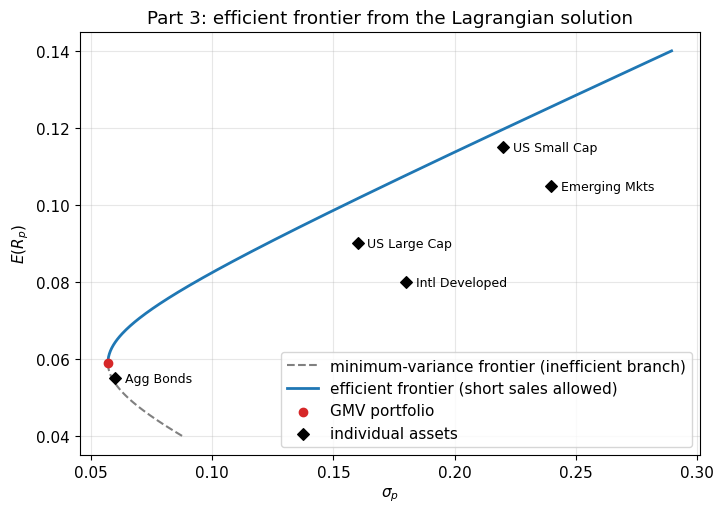

In [8]:
# --- sweep the whole frontier, vectorized (no re-solving, no loop) -----------
Rp_grid  = np.linspace(0.04, 0.14, 400)                       # target returns
X_grid   = g_vec[None, :] + Rp_grid[:, None] * h_vec[None, :] # shape (400, n)
sd_grid  = np.sqrt((A_ * Rp_grid**2 - 2 * B_ * Rp_grid + C_) / D_)

# verify the hyperbola formula against the raw quadratic form
sd_check = np.sqrt(np.einsum("ij,jk,ik->i", X_grid, Sigma, X_grid))
print("max |hyperbola - X'SigmaX| :", f"{np.abs(sd_grid - sd_check).max():.2e}")

efficient = Rp_grid >= R_gmv          # upper branch only

fig, ax = plt.subplots()
ax.plot(sd_grid[~efficient], Rp_grid[~efficient], "--", color="gray",
        label="minimum-variance frontier (inefficient branch)")
ax.plot(sd_grid[efficient], Rp_grid[efficient], color="tab:blue", lw=2,
        label="efficient frontier (short sales allowed)")
ax.scatter([sd_gmv], [R_gmv], color="tab:red", zorder=5, label="GMV portfolio")
ax.scatter(sd, R, color="black", marker="D", s=35, zorder=5, label="individual assets")
for name, s, r in zip(names, sd, R):
    ax.annotate(name, (s, r), textcoords="offset points", xytext=(7, -3), fontsize=9)
ax.set_xlabel(r"$\sigma_p$"); ax.set_ylabel(r"$E(R_p)$")
ax.set_title("Part 3: efficient frontier from the Lagrangian solution")
ax.legend(loc="lower right"); plt.show()

In [9]:
# --- weights at selected points along the frontier ---------------------------
targets = np.sort(np.array([0.055, R_gmv, 0.065, 0.07, 0.085, 0.10, 0.115, 0.13]))
W = g_vec[None, :] + targets[:, None] * h_vec[None, :]

table = pd.DataFrame(W, columns=names)
table.insert(0, "Rp* target", targets)
table["sigma_p"]  = np.sqrt(np.einsum("ij,jk,ik->i", W, Sigma, W))
table["sum(X)"]   = W.sum(axis=1)
table["sum|X|"]   = np.abs(W).sum(axis=1)
print("Frontier weights as the target return rises (negative = short sale)\n")
print(table.to_string(index=False))

Frontier weights as the target return rises (negative = short sale)



 Rp* target  US Large Cap  US Small Cap  Intl Developed  Emerging Mkts  Agg Bonds  sigma_p  sum(X)  sum|X|
     0.0550        0.0737       -0.0544          0.0640        -0.0183     0.9350   0.0586  1.0000  1.1454
     0.0590        0.0796        0.0038          0.0212         0.0086     0.8868   0.0569  1.0000  1.0000
     0.0650        0.0886        0.0921         -0.0437         0.0494     0.8137   0.0607  1.0000  1.0875
     0.0700        0.0961        0.1653         -0.0976         0.0832     0.7531   0.0688  1.0000  1.1952
     0.0850        0.1184        0.3850         -0.2592         0.1847     0.5711   0.1075  1.0000  1.5185
     0.1000        0.1408        0.6047         -0.4209         0.2862     0.3891   0.1546  1.0000  1.8417
     0.1150        0.1632        0.8244         -0.5825         0.3877     0.2072   0.2044  1.0000  2.1650
     0.1300        0.1856        1.0442         -0.7441         0.4892     0.0252   0.2553  1.0000  2.4883


**Interpretation.** Reading down the table, the mechanics of the frontier are visible: bonds fall from
~87% to ~5% as the target return rises, small caps climb past 100%, and international developed goes
progressively *short*. That short position is the interesting one — international has the worst
return-per-unit-risk of the equity block and is highly correlated with the other equities, so the optimizer
funds cheaper exposure by selling it and buying small cap and EM. `sum(X)` stays at exactly 1 everywhere
(the budget constraint binds), while `sum|X|` rises above 1 as soon as shorting starts. That gap between
$\sum X_i$ and $\sum|X_i|$ is exactly what Part 6 restricts.

The frontier is a hyperbola in $(\sigma_p, R_p)$ space, and the GMV portfolio is its leftmost point, as the
plot confirms. Everything below the red dot is the inefficient lower branch: same risk, less return.

## Part 4 — Tangency portfolio: maximizing the Sharpe ratio

Now maximize the reward-to-variability ratio

$$\theta = \frac{E(R_p) - R_f}{\sigma_p} = \frac{X'R - R_f}{\sqrt{X'\Sigma X}}
\qquad \text{s.t.}\quad X'\mathbf{1}=1$$

Setting $\partial\theta/\partial X_i = 0$ and clearing denominators gives, for every asset $i$,

$$R_i - R_f = \sum_{j=1}^{n} Z_j \sigma_{ij}, \qquad\text{i.e.}\qquad \Sigma Z = R - R_f\mathbf{1}$$

where $Z_j = \lambda X_j$ absorbs a positive scale factor $\lambda = \theta/\sigma_p$. The $Z_i$ are not
weights — they only become weights after normalizing, which is where $X'\mathbf{1}=1$ re-enters:

$$X_i = \frac{Z_i}{\sum_j Z_j}$$

This is the EGBG "solve for $Z$, then scale" recipe, and it is a *linear* system: the nonlinear Sharpe
maximization collapses to $n$ equations because the objective is scale-invariant.

In [10]:
excess = R - Rf * one
Z = np.linalg.solve(Sigma, excess)          # Sigma Z = R - Rf*1
X_tan = Z / Z.sum()                         # normalize so weights sum to 1

print("Z (unscaled solution):", np.round(Z, 4), "  sum(Z) =", round(Z.sum(), 4), "\n")
R_tan, sd_tan = summarize(X_tan, f"Tangency portfolio (Rf = {Rf:.1%})")
theta_tan = (R_tan - Rf) / sd_tan

# The tangency portfolio must also lie on the Part 3 frontier: check it.
X_check = g_vec + h_vec * R_tan
print("Same portfolio from the Part 3 frontier formula? max|diff| =",
      f"{np.abs(X_check - X_tan).max():.2e}")

# theta must beat every individual asset and the GMV portfolio
print(f"\nSharpe of tangency portfolio : {theta_tan:.4f}")
print(f"Sharpe of GMV portfolio      : {(R_gmv - Rf) / sd_gmv:.4f}")
print(f"Best single-asset Sharpe     : {((R - Rf) / sd).max():.4f} "
      f"({names[int(((R - Rf) / sd).argmax())]})")

Z (unscaled solution):

 [ 0.3418  1.2034 -0.8189  0.5748  1.4661]   sum(Z) = 2.7672 

Tangency portfolio (Rf = 5.0%)
        US Large Cap  US Small Cap  Intl Developed  Emerging Mkts  Agg Bonds
weight        0.1235        0.4349         -0.2959         0.2077     0.5298
  E(Rp) = 8.8403%   sigma_p = 11.7803%   sum(X) = 1.0000   theta = 0.3260

Same portfolio from the Part 3 frontier formula? max|diff| = 8.88e-16

Sharpe of tangency portfolio : 0.3260
Sharpe of GMV portfolio      : 0.1576
Best single-asset Sharpe     : 0.2955 (US Small Cap)


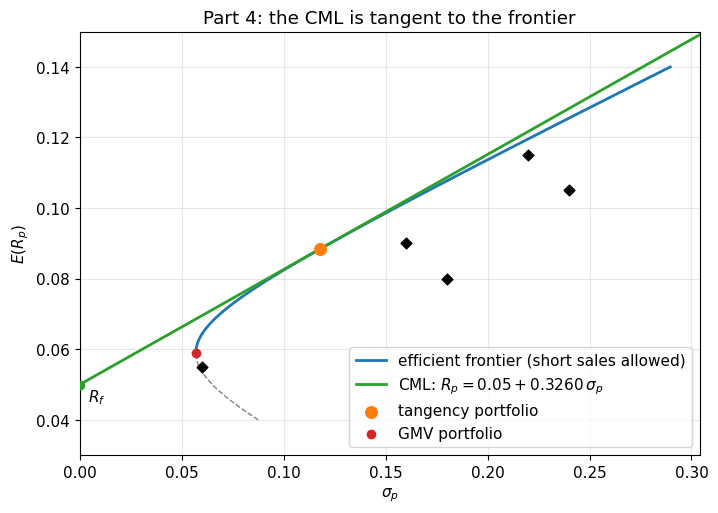

CML touches the frontier at sigma_p = 0.1167 (tangency sigma_p = 0.1178)


In [11]:
# --- Capital Market Line ----------------------------------------------------
sd_cml = np.linspace(0, sd_grid.max() * 1.05, 100)
cml    = Rf + theta_tan * sd_cml            # Rp = Rf + theta * sigma_p

fig, ax = plt.subplots()
ax.plot(sd_grid[~efficient], Rp_grid[~efficient], "--", color="gray", lw=1)
ax.plot(sd_grid[efficient], Rp_grid[efficient], color="tab:blue", lw=2,
        label="efficient frontier (short sales allowed)")
ax.plot(sd_cml, cml, color="tab:green", lw=2,
        label=fr"CML: $R_p = {Rf:.2f} + {theta_tan:.4f}\,\sigma_p$")
ax.scatter([0], [Rf], color="tab:green", zorder=5)
ax.annotate("$R_f$", (0, Rf), textcoords="offset points", xytext=(6, -12))
ax.scatter([sd_tan], [R_tan], color="tab:orange", s=70, zorder=6, label="tangency portfolio")
ax.scatter([sd_gmv], [R_gmv], color="tab:red", zorder=5, label="GMV portfolio")
ax.scatter(sd, R, color="black", marker="D", s=30, zorder=5)
ax.set_xlim(0, sd_grid.max() * 1.05); ax.set_ylim(0.03, 0.15)
ax.set_xlabel(r"$\sigma_p$"); ax.set_ylabel(r"$E(R_p)$")
ax.set_title("Part 4: the CML is tangent to the frontier")
ax.legend(loc="lower right"); plt.show()

# numerical check of tangency: find where the CML and the frontier come closest
frontier_at = np.interp(sd_cml, sd_grid[efficient], Rp_grid[efficient])
touch = np.abs(cml - frontier_at).argmin()
print(f"CML touches the frontier at sigma_p = {sd_cml[touch]:.4f} "
      f"(tangency sigma_p = {sd_tan:.4f})")

**Interpretation.** The tangency portfolio holds ~53% bonds, ~43% small cap and ~21% EM, funded partly by
a ~30% short in international developed. Its Sharpe ratio beats every individual asset and beats the GMV
portfolio, which is the whole point: the GMV portfolio minimizes risk, not risk-adjusted return.

The CML touches the frontier at exactly one point and lies weakly below it everywhere else. Its slope *is*
$\theta$, so "maximize the Sharpe ratio" and "find the steepest line from $R_f$ that still touches the
feasible set" are the same problem stated two ways. Note that bonds survive at 53% despite an excess return of
only 0.5% — near-zero correlation with equities makes them a risk-reducer, not a return source.

## Part 5 — No short sales: quadratic programming and Kuhn–Tucker

Add $X_i \ge 0$ for all $i$. These are *inequality* constraints, so plain Lagrange multipliers are no longer
enough; the Kuhn–Tucker (KKT) conditions take over. Write the Lagrangian with one multiplier $\mu_i \ge 0$
per non-negativity constraint:

$$L = \tfrac{1}{2}X'\Sigma X - \lambda_1(X'R - R_p^{*}) - \lambda_2(X'\mathbf{1}-1) - \sum_i \mu_i X_i$$

The KKT conditions are:

| | condition |
|---|---|
| stationarity | $(\Sigma X)_i - \lambda_1 R_i - \lambda_2 - \mu_i = 0$ for all $i$ |
| primal feasibility | $X'R = R_p^{*}$, $X'\mathbf{1}=1$, $X_i \ge 0$ |
| dual feasibility | $\mu_i \ge 0$ |
| complementary slackness | $\mu_i X_i = 0$ for all $i$ |

Complementary slackness is the whole story: for any asset actually held ($X_i>0$) we need $\mu_i = 0$, so the
old equality-constrained condition $(\Sigma X)_i = \lambda_1 R_i + \lambda_2$ still holds. For an asset at a
**corner solution** ($X_i = 0$), $\mu_i$ is allowed to be strictly positive, and

$$\mu_i = (\Sigma X)_i - \lambda_1 R_i - \lambda_2 \;\ge\; 0$$

is the *reduced cost* of that asset: the marginal increase in the objective from being forced to hold a tiny
bit of it. A positive $\mu_i$ says "this asset would want a negative weight if it were allowed one".

**Recovering the multipliers.** `scipy` does not hand back clean duals, so we recover them from the KKT system
itself. Take the free set $F = \{i : X_i > 0\}$, where $\mu_i = 0$. Then

$$(\Sigma X)_i = \lambda_1 R_i + \lambda_2 \quad \text{for } i \in F$$

is an overdetermined linear system in $(\lambda_1, \lambda_2)$; solve it by least squares, then read off
$\mu = \Sigma X - \lambda_1 R - \lambda_2\mathbf{1}$ for *every* asset. The $\mu_i$ of the free assets should
come back at ~0 — that is the residual check that the solver actually converged to a KKT point.

In [12]:
TOL = 1e-7

# --- objective, gradient and constraint functions (named, not lambdas) ------
def variance_obj(X):
    '''(1/2) X'Sigma X  -- the objective of every problem in this notebook.'''
    return 0.5 * X @ Sigma @ X

def variance_grad(X):
    '''d/dX of the objective = Sigma X  -- the first term of dL/dX.'''
    return Sigma @ X

def budget_con(X):
    '''X'1 - 1 = 0'''
    return X.sum() - 1.0

def budget_jac(X):
    return one

def return_con(X, Rp_target):
    '''X'R - Rp* = 0'''
    return X @ R - Rp_target

def return_jac(X, Rp_target):
    return R

def solve_no_short(Rp_target, x0=None):
    '''min (1/2) X'Sigma X  s.t.  X'R = Rp*, X'1 = 1, X >= 0.   SLSQP with analytic gradients.'''
    cons = [{"type": "eq", "fun": budget_con, "jac": budget_jac},
            {"type": "eq", "fun": return_con, "jac": return_jac, "args": (Rp_target,)}]
    if x0 is None:
        x0 = np.full(n, 1.0 / n)
    return minimize(variance_obj, x0, method="SLSQP", jac=variance_grad,
                    bounds=[(0.0, None)] * n, constraints=cons,
                    options={"maxiter": 500, "ftol": 1e-14})

def kkt_multipliers(X):
    '''Recover (lambda_1, lambda_2, mu) from the KKT stationarity conditions.'''
    free = X > TOL
    M = np.column_stack([R[free], one[free]])              # rows: lambda_1*R_i + lambda_2
    (l1, l2), *_ = np.linalg.lstsq(M, (Sigma @ X)[free], rcond=None)
    mu = Sigma @ X - l1 * R - l2 * one                     # = dL/dX_i before subtracting mu
    return l1, l2, mu

# feasible target-return range without shorting: [min(R), max(R)]
print(f"Attainable returns with X >= 0: {R.min():.2%} to {R.max():.2%}")

# constrained global minimum variance portfolio
res_gmv_ns = minimize(variance_obj, np.full(n, 1 / n), method="SLSQP", jac=variance_grad,
                      bounds=[(0.0, None)] * n,
                      constraints=[{"type": "eq", "fun": budget_con, "jac": budget_jac}])
X_gmv_ns = res_gmv_ns.x
R_gmv_ns, sd_gmv_ns = summarize(X_gmv_ns, "GMV portfolio, no short sales")

Attainable returns with X >= 0: 5.50% to 11.50%
GMV portfolio, no short sales
        US Large Cap  US Small Cap  Intl Developed  Emerging Mkts  Agg Bonds
weight        0.0985        0.0000          0.0162         0.0013     0.8839
  E(Rp) = 5.8921%   sigma_p = 5.6972%   sum(X) = 1.0000   theta = 0.1566



In [13]:
# --- KKT inspection at three points on the constrained frontier --------------
for Rp_star in [0.070, 0.090, 0.110]:
    res = solve_no_short(Rp_star)
    X   = np.where(res.x < TOL, 0.0, res.x)          # clean numerical dust
    l1, l2, mu = kkt_multipliers(X)
    at_corner = X <= TOL

    print("=" * 78)
    print(f"Target Rp* = {Rp_star:.2%}   |  solver status {res.status} ({res.message})")
    print(f"sigma_p = {port_sd(X):.4%}   E(Rp) = {port_return(X):.4%}   sum(X) = {X.sum():.6f}")
    print(f"lambda_1 = {l1: .6f}   lambda_2 = {l2: .6f}")
    print(pd.DataFrame({"X_i": X,
                        "at corner (X=0)": at_corner,
                        "mu_i (reduced cost)": mu,
                        "X_i * mu_i": X * mu}, index=names))
    print(f"  corner assets      : {[names[i] for i in np.flatnonzero(at_corner)] or 'none'}")
    print(f"  min mu_i           : {mu.min(): .3e}   (dual feasibility needs mu >= 0)")
    print(f"  max |X_i * mu_i|   : {np.abs(X * mu).max():.3e}   (complementary slackness)")
    print(f"  unconstrained X    : {np.round(g_vec + h_vec * Rp_star, 4)}")
    print()

Target Rp* = 7.00%   |  solver status 0 (Optimization terminated successfully)
sigma_p = 6.9711%   E(Rp) = 7.0000%   sum(X) = 1.000000
lambda_1 =  0.149111   lambda_2 = -0.005578
                   X_i  at corner (X=0)  mu_i (reduced cost)  X_i * mu_i
US Large Cap    0.0396            False              -0.0000     -0.0000
US Small Cap    0.1761            False               0.0000      0.0000
Intl Developed  0.0000             True               0.0013      0.0000
Emerging Mkts   0.0610            False              -0.0000     -0.0000
Agg Bonds       0.7233            False               0.0000      0.0000
  corner assets      : ['Intl Developed']
  min mu_i           : -7.655e-15   (dual feasibility needs mu >= 0)
  max |X_i * mu_i|   : 2.693e-15   (complementary slackness)
  unconstrained X    : [ 0.0961  0.1653 -0.0976  0.0832  0.7531]

Target Rp* = 9.00%   |  solver status 0 (Optimization terminated successfully)
sigma_p = 12.7928%   E(Rp) = 9.0000%   sum(X) = 1.000000
lambda_1 

**Interpretation.** At every target the corner assets are exactly the ones the unconstrained solution
wanted to short (compare the last line of each block): international developed is pinned at zero throughout,
and US large cap joins it at higher targets, squeezed out by small cap which offers more return with similar
factor exposure.

The three KKT checks all pass: $\mu_i \ge 0$ everywhere, $\mu_i \approx 0$ for every held asset, and
$X_i\mu_i \approx 0$ to machine precision. The size of $\mu_i$ is economically readable — it grows with the
target return, because the higher the target, the more the optimizer wishes it could short international
developed to fund small cap, and the more binding that zero floor becomes.

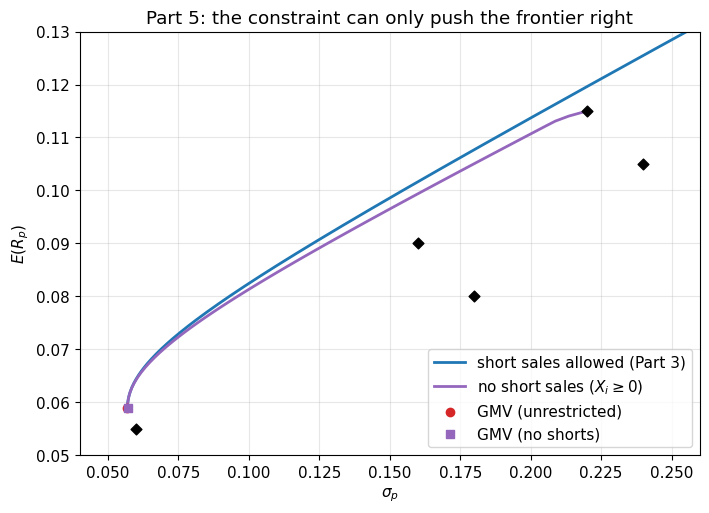

min (sigma_noshort - sigma_unrestricted) = -1.388e-17  (must be >= 0)
max extra risk from the constraint       = 1.5582% at Rp* = 11.50%


In [14]:
# --- trace the whole no-short-sales frontier ---------------------------------
Rp_ns = np.linspace(R_gmv_ns, R.max(), 60)          # efficient part only

sd_ns, W_ns = [], []
warm = np.full(n, 1 / n)
for t in Rp_ns:                                      # each target needs its own QP solve
    res = solve_no_short(t, x0=warm)
    warm = res.x                                     # warm start the next solve
    X = np.where(res.x < TOL, 0.0, res.x)
    sd_ns.append(port_sd(X)); W_ns.append(X)
sd_ns = np.array(sd_ns); W_ns = np.array(W_ns)

fig, ax = plt.subplots()
ax.plot(sd_grid[efficient], Rp_grid[efficient], color="tab:blue", lw=2,
        label="short sales allowed (Part 3)")
ax.plot(sd_ns, Rp_ns, color="tab:purple", lw=2, label=r"no short sales ($X_i \geq 0$)")
ax.scatter([sd_gmv], [R_gmv], color="tab:red", zorder=5, label="GMV (unrestricted)")
ax.scatter([sd_gmv_ns], [R_gmv_ns], color="tab:purple", marker="s", zorder=5, label="GMV (no shorts)")
ax.scatter(sd, R, color="black", marker="D", s=30, zorder=5)
ax.set_xlim(0.04, 0.26); ax.set_ylim(0.05, 0.13)
ax.set_xlabel(r"$\sigma_p$"); ax.set_ylabel(r"$E(R_p)$")
ax.set_title("Part 5: the constraint can only push the frontier right")
ax.legend(loc="lower right"); plt.show()

# the dominance relationship, numerically
sd_un_at = np.sqrt((A_ * Rp_ns**2 - 2 * B_ * Rp_ns + C_) / D_)
print(f"min (sigma_noshort - sigma_unrestricted) = {(sd_ns - sd_un_at).min():.3e}  (must be >= 0)")
print(f"max extra risk from the constraint       = {(sd_ns - sd_un_at).max():.4%} "
      f"at Rp* = {Rp_ns[int((sd_ns - sd_un_at).argmax())]:.2%}")

In [15]:
# --- weights along the constrained frontier ---------------------------------
pick = np.linspace(0, len(Rp_ns) - 1, 8).astype(int)
tab_ns = pd.DataFrame(W_ns[pick], columns=names)
tab_ns.insert(0, "Rp*", Rp_ns[pick])
tab_ns["sigma_p"] = sd_ns[pick]
tab_ns["# at corner"] = (W_ns[pick] <= TOL).sum(axis=1)
print("No-short-sales frontier: weights and corner count\n")
print(tab_ns.to_string(index=False))

No-short-sales frontier: weights and corner count

    Rp*  US Large Cap  US Small Cap  Intl Developed  Emerging Mkts  Agg Bonds  sigma_p  # at corner
 0.0589        0.0795        0.0030          0.0218         0.0082     0.8875   0.0569            0
 0.0665        0.0561        0.1210          0.0000         0.0460     0.7769   0.0632            1
 0.0741        0.0201        0.2415          0.0000         0.0787     0.6597   0.0795            1
 0.0827        0.0000        0.3680          0.0000         0.1121     0.5199   0.1042            2
 0.0903        0.0000        0.4726          0.0000         0.1386     0.3888   0.1289            2
 0.0988        0.0000        0.5904          0.0000         0.1684     0.2412   0.1581            2
 0.1064        0.0000        0.6950          0.0000         0.1949     0.1101   0.1849            2
 0.1150        0.0000        1.0000          0.0000         0.0000     0.0000   0.2200            4


In [16]:
# --- linear fits Rp = a + b*sigma_p over a common return range --------------
lo, hi = R_gmv_ns, R.max()          # both frontiers exist on this interval
mask_un = (Rp_grid >= lo) & (Rp_grid <= hi)

def fit_line(sigma, Rp):
    '''OLS of Rp on sigma_p: returns (intercept a, slope b, R^2).'''
    b, a = np.polyfit(sigma, Rp, 1)
    pred = a + b * sigma
    r2 = 1 - ((Rp - pred) ** 2).sum() / ((Rp - Rp.mean()) ** 2).sum()
    return a, b, r2

a_un, b_un, r2_un = fit_line(sd_grid[mask_un], Rp_grid[mask_un])
a_ns, b_ns, r2_ns = fit_line(sd_ns, Rp_ns)

print(f"Fitted over E(Rp) in [{lo:.2%}, {hi:.2%}]\n")
print(f"Short sales allowed : Rp = {a_un:.4f} + {b_un:.4f} * sigma_p   (R^2 = {r2_un:.4f})")
print(f"No short sales      : Rp = {a_ns:.4f} + {b_ns:.4f} * sigma_p   (R^2 = {r2_ns:.4f})")
print(f"\nSlope difference    : {b_un - b_ns:.4f}  ({(b_un / b_ns - 1) * 100:.2f}% steeper "
      f"when shorting is allowed)")
print(f"Max Sharpe (tangency, unrestricted) for reference: {theta_tan:.4f}")

Fitted over E(Rp) in [5.89%, 11.50%]

Short sales allowed : Rp = 0.0454 + 0.3515 * sigma_p   (R^2 = 0.9871)
No short sales      : Rp = 0.0467 + 0.3262 * sigma_p   (R^2 = 0.9859)

Slope difference    : 0.0253  (7.75% steeper when shorting is allowed)
Max Sharpe (tangency, unrestricted) for reference: 0.3260


**Interpretation.** The no-short-sales frontier lies weakly to the right of the unrestricted one
everywhere and never crosses it — the printed minimum gap is zero to machine precision ($\sim10^{-17}$), and
it *has* to be non-negative, because $\{X : X\ge 0\}$ is a subset of the unrestricted feasible set, so
constraining can only raise the attained minimum variance. The two frontiers are indistinguishable near the
GMV point (where the unrestricted solution barely shorts anything) and separate steadily as the target return
rises, since that is where the unrestricted solution wants its largest short.

Two structural differences worth noting. First, the constrained frontier *ends* at the highest-return asset
(11.5%): without shorting you cannot lever past your best asset, whereas the unrestricted frontier continues
indefinitely. Second, the constrained frontier is piecewise — it is made of linear segments joined at
**corner portfolios**, the targets at which an asset enters or leaves the solution (visible in the
"# at corner" column). This is Markowitz's critical line algorithm in slow motion.

The fitted slopes reproduce the textbook comparison: the short-sales-allowed frontier is steeper, meaning more
return per unit of risk. Two caveats on those numbers: a straight line is only an approximation to a
hyperbola (see the $R^2$), and the slope depends on the return range you fit over, so it is a comparison
statistic, not a structural parameter. The clean version of "slope" is the tangency Sharpe ratio.

## Part 6 — Lintner's alternative short-sale definition

The Part 3 formulation lets shorts be free: $\sum_i X_i = 1$ counts a $-50\%$ position as $-0.5$, so a
portfolio can be $150\%$ long and $50\%$ short with no penalty. Lintner's convention instead requires that
the *gross* exposure be normalized:

$$\sum_i \lvert X_i \rvert = 1 \quad\text{instead of}\quad \sum_i X_i = 1$$

which reflects the idea that short proceeds are held as collateral rather than being freely reinvested.
The constraint is non-differentiable at $X_i = 0$, so we use the standard convex reformulation: split each
weight into a long and short piece,

$$X_i = u_i - v_i, \qquad u_i, v_i \ge 0, \qquad \sum_i (u_i + v_i) = 1$$

Usually at most one of $u_i, v_i$ is nonzero, so $u_i + v_i = |X_i|$ and the constraint becomes linear —
convex, and safe for SLSQP. Two things to watch:

- $\sum_i X_i \le 1$ here. Shorting no longer frees up cash to reinvest, so a portfolio that shorts is not
  fully invested in net terms. This is exactly Lintner's economic point.
- If both $u_i>0$ and $v_i>0$ at the solution, the split is *slack* and the solver has actually optimized
  $\sum_i|X_i| \le 1$ rather than $=1$. That happens when the target return is reachable with less than full
  gross exposure. The code checks for it and excludes those points instead of quietly mislabelling them.

In [17]:
def net_weights(uv):
    '''X = u - v, where uv = [u, v] stacks the long and short legs.'''
    return uv[:n] - uv[n:]

def lintner_obj(uv):
    X = net_weights(uv)
    return 0.5 * X @ Sigma @ X

def lintner_grad(uv):
    '''dObj/du = Sigma X, dObj/dv = -Sigma X, by the chain rule through X = u - v.'''
    gradient = Sigma @ net_weights(uv)
    return np.concatenate([gradient, -gradient])

def gross_exposure_con(uv):
    '''sum(u) + sum(v) - 1 = 0   (equals sum|X| - 1 when no u_i, v_i pair is both positive)'''
    return uv.sum() - 1.0

def gross_exposure_jac(uv):
    return np.ones(2 * n)

def lintner_return_con(uv, Rp_target):
    return net_weights(uv) @ R - Rp_target

def lintner_return_jac(uv, Rp_target):
    return np.concatenate([R, -R])

def solve_lintner(Rp_target, x0=None):
    '''min (1/2)X'Sigma X  s.t.  X'R = Rp*, sum|X| = 1, using X = u - v with u, v >= 0.'''
    cons = [{"type": "eq", "fun": gross_exposure_con, "jac": gross_exposure_jac},
            {"type": "eq", "fun": lintner_return_con, "jac": lintner_return_jac,
             "args": (Rp_target,)}]
    if x0 is None:
        x0 = np.full(2 * n, 1.0 / (2 * n))
    res = minimize(lintner_obj, x0, method="SLSQP", jac=lintner_grad,
                   bounds=[(0.0, None)] * (2 * n), constraints=cons,
                   options={"maxiter": 2000, "ftol": 1e-16})
    return net_weights(res.x), res

Rp_lin = np.linspace(R_gmv_ns, R.max(), 40)
sd_lin, W_lin, gross_lin = [], [], []
warm_lin = np.full(2 * n, 1.0 / (2 * n))
for t in Rp_lin:
    X, res = solve_lintner(t, x0=warm_lin)
    warm_lin = res.x
    X = np.where(np.abs(X) < TOL, 0.0, X)
    sd_lin.append(port_sd(X)); W_lin.append(X); gross_lin.append(np.abs(X).sum())
sd_lin = np.array(sd_lin); W_lin = np.array(W_lin); gross_lin = np.array(gross_lin)

# Where the u/v split is exact, sum|X| = 1. Where it is slack (both u_i, v_i > 0),
# the solver has really solved the relaxation sum|X| <= 1 -- flag and exclude those.
tight = np.abs(gross_lin - 1.0) < 1e-6
print(f"Points where sum|X| = 1 holds exactly: {tight.sum()} of {len(Rp_lin)}")
if (~tight).any():
    print(f"  slack at Rp* = {np.round(Rp_lin[~tight], 4)} "
          f"(sum|X| = {np.round(gross_lin[~tight], 4)}) -- excluded from the plot")

shorts = (W_lin < -TOL).any(axis=1)
print(f"Targets with at least one short position: {shorts.sum()} of {len(Rp_lin)}"
      f"  (up to Rp* = {Rp_lin[shorts].max():.4%})" if shorts.any() else "No shorts taken")

tab_lin = pd.DataFrame(W_lin[::6], columns=names)
tab_lin.insert(0, "Rp*", Rp_lin[::6])
tab_lin["sigma_p"] = sd_lin[::6]
tab_lin["sum(X)"]  = W_lin[::6].sum(axis=1)
tab_lin["sum|X|"]  = gross_lin[::6]
print("\nLintner frontier weights\n"); print(tab_lin.to_string(index=False))

sd_ns_at = np.interp(Rp_lin, Rp_ns, sd_ns)
sd_un_at_lin = np.sqrt((A_ * Rp_lin**2 - 2 * B_ * Rp_lin + C_) / D_)
comp = pd.DataFrame({"Rp*": Rp_lin, "unrestricted": sd_un_at_lin,
                     "Lintner": sd_lin, "no short": sd_ns_at})[tight]
print("\nsigma_p under the three regimes (every 6th point)\n")
print(comp.iloc[::6].to_string(index=False))

diff = (sd_lin - sd_un_at_lin)[tight]
below = diff < -1e-9
print(f"\nLintner sigma below the unrestricted frontier at {below.sum()} of {tight.sum()} points"
      f" (max by {(-diff[below]).max():.4%})" if below.any() else
      "\nLintner never dips below the unrestricted frontier")
print(f"These are exactly the targets where sum(X) < 1: "
      f"{np.round(Rp_lin[tight][W_lin[tight].sum(axis=1) < 1 - 1e-6], 4)}")

Points where sum|X| = 1 holds exactly: 39 of 40
  slack at Rp* = [0.0589] (sum|X| = [0.9788]) -- excluded from the plot
Targets with at least one short position: 4 of 40  (up to Rp* = 6.3234%)

Lintner frontier weights

    Rp*  US Large Cap  US Small Cap  Intl Developed  Emerging Mkts  Agg Bonds  sigma_p  sum(X)  sum|X|
 0.0589        0.0801        0.0644         -0.0251         0.0361     0.7731   0.0548  0.9286  0.9788
 0.0675        0.0513        0.1373          0.0000         0.0504     0.7611   0.0649  1.0000  1.0000
 0.0762        0.0104        0.2739          0.0000         0.0876     0.6281   0.0850  1.0000  1.0000
 0.0848        0.0000        0.3972          0.0000         0.1195     0.4834   0.1109  1.0000  1.0000
 0.0934        0.0000        0.5159          0.0000         0.1495     0.3346   0.1395  1.0000  1.0000
 0.1021        0.0000        0.6346          0.0000         0.1796     0.1858   0.1694  1.0000  1.0000
 0.1107        0.0000        0.7534          0.0000        

**Interpretation.** The Lintner frontier splits into two regimes here, and the second one is the
textbook case while the first is a wrinkle worth understanding.

**Above roughly a 6.4% target, shorts disappear entirely** and the Lintner frontier lies exactly on top of the
no-short-sales frontier (see the comparison table: the two $\sigma_p$ columns agree to four decimals). The
reason is a budget calculation. Under $\sum X_i = 1$, shorting \$1 of international developed hands you \$1
to spend elsewhere — a free lever. Under $\sum|X_i| = 1$, that same short *consumes* \$1 of gross budget, so
the round trip costs \$2 of budget to add \$1 of net long exposure. Once the target return is high enough
that every dollar of budget wants to sit in small cap and EM, that double toll stops being worth paying.
Give international a lower expected return and re-run — the shorts will persist much further up the frontier.

**Near the GMV end a handful of targets do short**, and at those the Lintner frontier can dip slightly
*left* of the unrestricted frontier rather than sitting between the two. That is not a solver error. Those are precisely
the points where $\sum X_i < 1$: short proceeds are collateral, not spendable cash, so the portfolio is not
fully invested in net terms, and scaling total exposure down mechanically lowers $\sigma_p$. The Lintner
feasible set is therefore *not* a subset of the $\sum X_i = 1$ set, so the frontiers are not strictly nested
at that end. If you want the clean nesting, charge the uninvested remainder to a cash account at $R_f$ (so
$R_p = X'R + (1 - \sum X_i) R_f$) or add $\sum X_i = 1$ as a third constraint — either restores comparability
at the cost of no longer being Lintner's formulation.

The broader lesson: the ordering
$\sigma_{\text{unrestricted}} \le \sigma_{\text{Lintner}} \le \sigma_{\text{no short}}$ holds when each
feasible set genuinely nests inside the previous one, and $\sum|X_i|=1$ quietly breaks that nesting by
relaxing what "fully invested" means. Worth checking the constraint set, not just the picture.

## Combined chart and summary

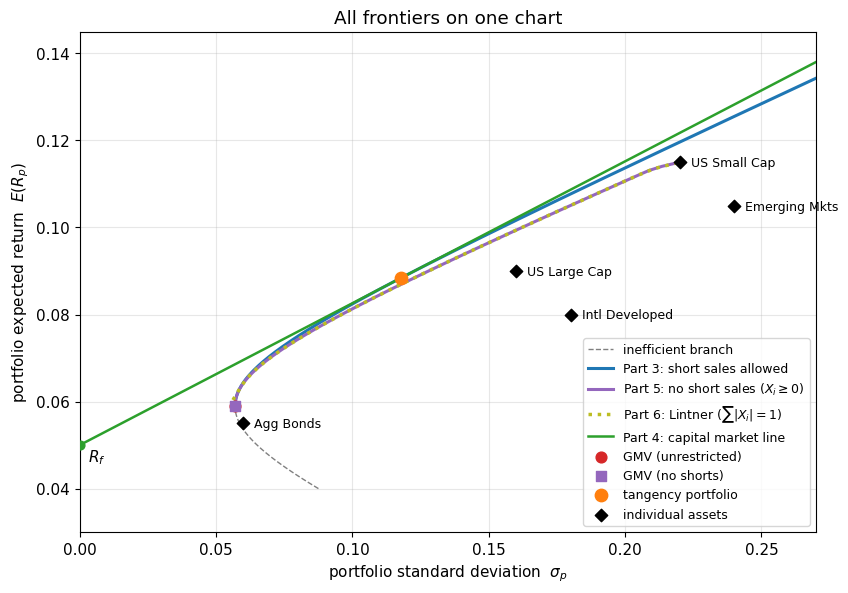

In [18]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))

ax.plot(sd_grid[~efficient], Rp_grid[~efficient], "--", color="gray", lw=1,
        label="inefficient branch")
ax.plot(sd_grid[efficient], Rp_grid[efficient], color="tab:blue", lw=2.2,
        label="Part 3: short sales allowed")
ax.plot(sd_ns, Rp_ns, color="tab:purple", lw=2.2, label=r"Part 5: no short sales ($X_i\geq0$)")
ax.plot(sd_lin[tight], Rp_lin[tight], color="tab:olive", lw=2.5, ls=":",
        label=r"Part 6: Lintner ($\sum|X_i|=1$)")
ax.plot(sd_cml, cml, color="tab:green", lw=1.8, label="Part 4: capital market line")

ax.scatter([sd_gmv], [R_gmv], color="tab:red", s=60, zorder=6, label="GMV (unrestricted)")
ax.scatter([sd_gmv_ns], [R_gmv_ns], color="tab:purple", marker="s", s=55, zorder=6,
           label="GMV (no shorts)")
ax.scatter([sd_tan], [R_tan], color="tab:orange", s=80, zorder=6, label="tangency portfolio")
ax.scatter([0], [Rf], color="tab:green", s=40, zorder=6)
ax.annotate("$R_f$", (0, Rf), textcoords="offset points", xytext=(6, -12))
ax.scatter(sd, R, color="black", marker="D", s=40, zorder=6, label="individual assets")
for name, s, r in zip(names, sd, R):
    ax.annotate(name, (s, r), textcoords="offset points", xytext=(8, -3), fontsize=9)

ax.set_xlim(0, 0.27); ax.set_ylim(0.03, 0.145)
ax.set_xlabel(r"portfolio standard deviation  $\sigma_p$")
ax.set_ylabel(r"portfolio expected return  $E(R_p)$")
ax.set_title("All frontiers on one chart")
ax.legend(loc="lower right", fontsize=9); plt.show()

In [19]:
summary = pd.DataFrame(
    [np.append(X_gmv,    [R_gmv,    sd_gmv,    (R_gmv - Rf) / sd_gmv]),
     np.append(X_tan,    [R_tan,    sd_tan,    theta_tan]),
     np.append(X_gmv_ns, [R_gmv_ns, sd_gmv_ns, (R_gmv_ns - Rf) / sd_gmv_ns])],
    index=["GMV (unrestricted)", "Tangency (unrestricted)", "GMV (no short sales)"],
    columns=names + ["E(Rp)", "sigma_p", "theta"])
print(summary.to_string())

                         US Large Cap  US Small Cap  Intl Developed  Emerging Mkts  Agg Bonds   E(Rp)  sigma_p   theta
GMV (unrestricted)             0.0796        0.0038          0.0212         0.0086     0.8868  0.0590   0.0569  0.1576
Tangency (unrestricted)        0.1235        0.4349         -0.2959         0.2077     0.5298  0.0884   0.1178  0.3260
GMV (no short sales)           0.0985        0.0000          0.0162         0.0013     0.8839  0.0589   0.0570  0.1566


### What to take away

1. **Equality constraints → Lagrange multipliers → a linear system.** Minimizing a quadratic subject to
   linear equalities has a closed-form solution; the FOCs $\Sigma X = \lambda_1 R + \lambda_2\mathbf{1}$ are
   literally the matrix we solved. No iteration required.
2. **The multipliers are prices, not bookkeeping.** $\lambda$ in Part 2 equals the GMV variance; $\lambda_1$
   in Part 3 is the marginal variance cost of one more unit of target return; $\mu_i$ in Part 5 is the
   marginal cost of the no-shorting rule for asset $i$.
3. **Inequality constraints → KKT → a quadratic program.** Complementary slackness $\mu_i X_i = 0$ splits the
   assets into a free set (old equality conditions apply) and a corner set (multiplier goes positive). The
   solution becomes piecewise linear in $R_p^*$, joined at corner portfolios.
4. **Shrinking the feasible set can only hurt.** Unrestricted $\subseteq$ Lintner $\subseteq$ no-short-sales
   in terms of achievable $\sigma_p$ at each target return, which is why the frontiers nest — and it is also
   why the no-short frontier stops at the best single asset.

### Things worth trying next

- Set `Rf` to 3% or 6% and re-run: watch the tangency portfolio slide along the frontier.
- Give international developed a lower expected return and re-run Part 6 — shorts appear and the Lintner
  frontier separates from the no-short one.
- Perturb one expected return by 50bp and compare frontier weights. Mean-variance weights are notoriously
  unstable in $R$; this is the standard motivation for shrinkage estimators and Black–Litterman.
- Add a max-weight constraint ($X_i \le 0.4$) and inspect the multipliers on the *upper* bounds.